# Final Project: Development of a Virtual Fitness Trainer

In recent years, we've observed an interesting trend: people are increasingly working out at home. Working out with a trainer at the gym is becoming a thing of the past, replaced by a new reality in which people exercise while watching a screen.

But without a trainer nearby, who can tell them if they're doing an exercise correctly?

Specifically for such cases, we want to create a virtual trainer that will help people exercise safely.

With our app, users can verify the correctness and effectiveness of their movements by simply uploading a video of their workout. The app will compare their movements with those of the trainer and provide recommendations.

## 1. Constructing a Frame of a Pose Through Key Points

The first stage of our project is dedicated to assessing human orientation in graphical format (Human Pose Skeleton).

Essentially, this is a set of coordinates that can be linked to describe a person's pose. Each coordinate in the skeleton is a key point. The correct connection between two parts is called a limb.

Example: a chain of transformations of an image of a running girl.

![Running girl skeleton](running_girl_skeleton.png)

To create the Human Pose Skeleton, we will use the Keypoint RCNN architecture, the implementation of which is presented in the torchvision library.

Keypoint RCNN has a ready-to-use implementation in the PyTorch wrapper. Using this model, we can easily detect keypoints of the human body (from the eyes to the ankles) in an image and obtain the reliability of these detections.

### 1.1 Import Dependencies

In [1]:
import torch
import torchvision
import torchvision.transforms as T

from PIL import Image

### 1.2 Define Constants

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


### 1.3 Load Model

Load the keypointrcnn model with the default weights.

In [3]:
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()
model.to(device)

KeypointRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640, 672, 704, 736, 768, 800), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.

### 1.4 Load Image

Load the image and transform it to a tensor.

In [4]:
def load_image(img_path):
    image = Image.open(img_path).convert("RGB")

    transform = T.Compose([
        T.ToTensor(),  # converts to [0,1] and CHW
    ])

    img_tensor = transform(image)
    img_tensor = img_tensor.to(device)
    
    return img_tensor, image

Load and output a test image.

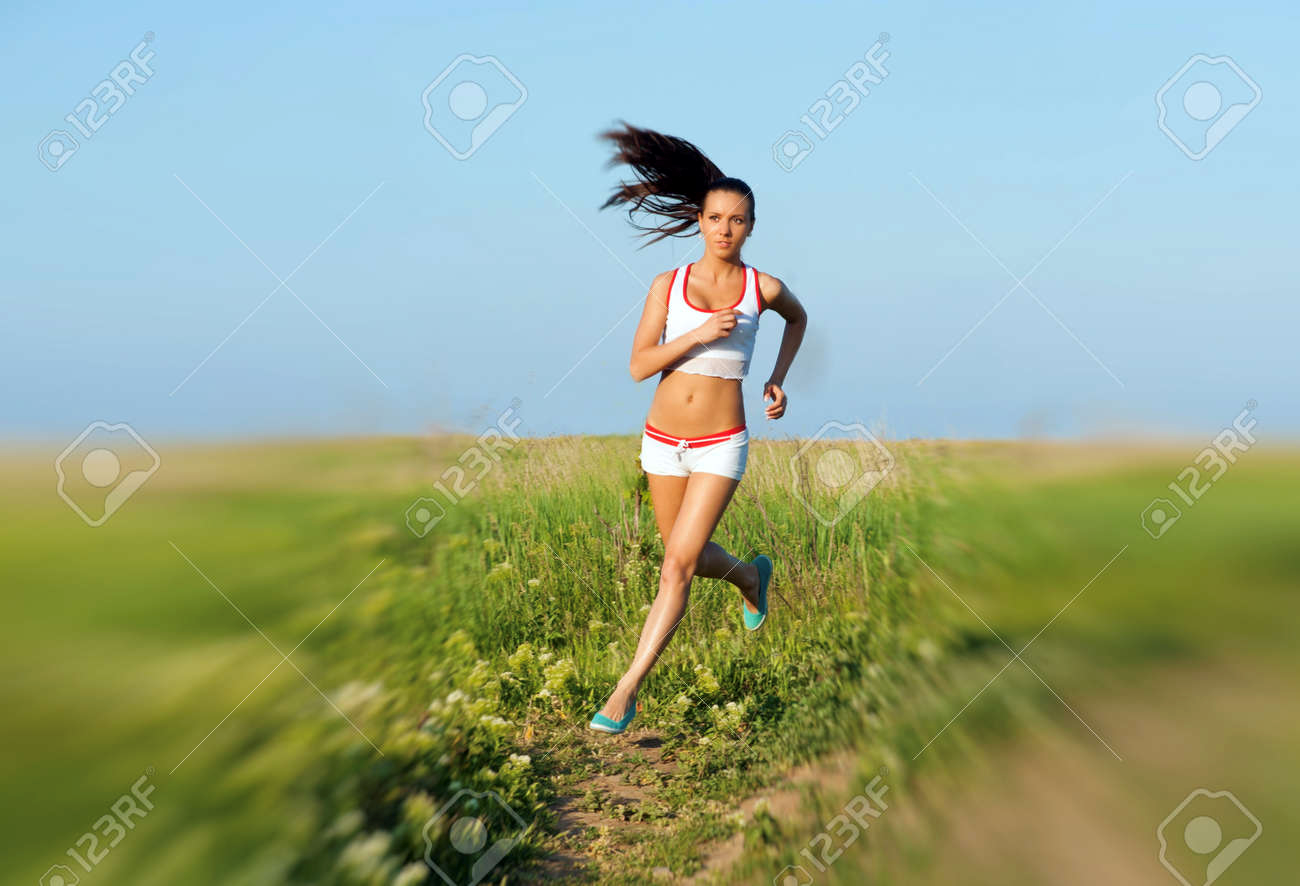

In [5]:
img_tensor, original_image = load_image("running_girl.png")
display(original_image)

### 1.5 Run Inference

In [6]:
with torch.no_grad():
    predictions = model([img_tensor])
    output = predictions[0]
    output


Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Impacting Interactivity (0000000e:kIOGPUCommandBufferCallbackErrorImpactingInteractivity)
	<AGXG14XFamilyCommandBuffer: 0x169dab980>
    label = <none> 
    device = <AGXG14SDevice: 0x112c31e00>
        name = Apple M2 Pro 
    commandQueue = <AGXG14XFamilyCommandQueue: 0x15131b000>
        label = <none> 
        device = <AGXG14SDevice: 0x112c31e00>
            name = Apple M2 Pro 
    retainedReferences = 1
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Impacting Interactivity (0000000e:kIOGPUCommandBufferCallbackErrorImpactingInteractivity)
	<AGXG14XFamilyCommandBuffer: 0x169dac420>
    label = <none> 
    device = <AGXG14SDevice: 0x112c31e00>
        name = Apple M2 Pro 
    commandQueue = <AGXG14XFamilyCommandQueue: 0x15131b000>
        la